<a href="https://colab.research.google.com/github/0xjessie21/data-science-2026/blob/main/Pertemuan5_MOHAMMAD_RIYAN_SYAIFUNAHAR_240401010292.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 5 — Visualisasi Data: Dashboard Visualisasi Statis
**Nama:** MOHAMMAD RIYAN SYAIFUNAHAR  
**NIM:** 240401010292  
**Mata Kuliah:** Pengantar Data Science  
**Dataset:** Tips (244 baris, 7 kolom — total_bill, tip, sex, smoker, day, time, size)

---
## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='Set2')
print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## Langkah 1 — Load & Inspect Dataset

In [2]:
df = sns.load_dataset('tips')

print('Shape:', df.shape)
print('\nTipe data per kolom:')
print(df.dtypes)

Shape: (244, 7)

Tipe data per kolom:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object


In [3]:
print('5 Baris Pertama:')
df.head()

5 Baris Pertama:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
print('Statistik Deskriptif:')
df.describe().round(2)

Statistik Deskriptif:


,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


In [5]:
print('Missing values per kolom:')
print(df.isnull().sum())

print('\nDistribusi per Hari:')
print(df['day'].value_counts())
print('\nDistribusi per Waktu Makan:')
print(df['time'].value_counts())

Missing values per kolom:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Distribusi per Hari:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

Distribusi per Waktu Makan:
time
Dinner    176
Lunch      68
Name: count, dtype: int64


**Temuan Eksplorasi Awal:**  
- Dataset Tips memiliki **244 baris** dan **7 kolom** (3 numerik, 4 kategorik)  
- Tidak ada missing values pada seluruh kolom  
- Rata-rata total tagihan **$19.79** dengan tip rata-rata **$2.99**  
- Data dikumpulkan pada 4 hari: Thu, Fri, Sat, Sun — dengan Sabtu paling banyak (87 observasi)  
- Mayoritas transaksi terjadi pada waktu Dinner (176 dari 244)

---
## Langkah 2 — Grafik 1: Bar Chart
### Rata-rata Total Tagihan per Hari

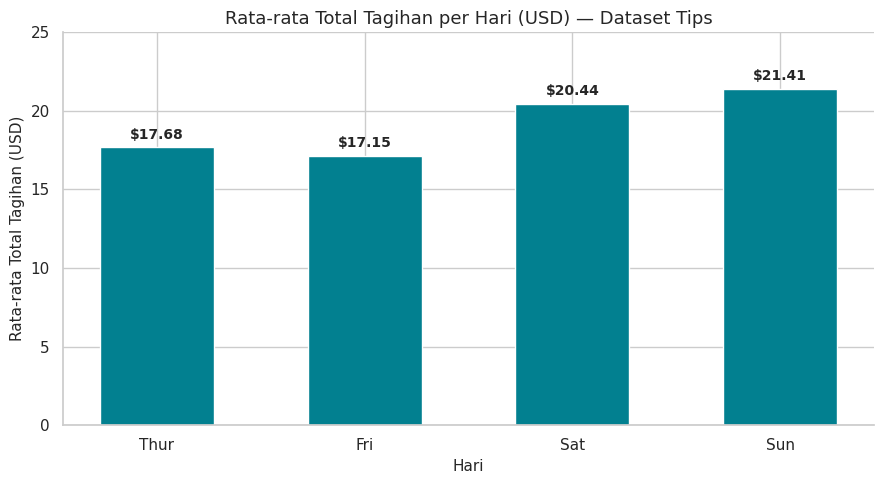

In [6]:
urutan_hari = ['Thur', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(9, 5))

avg_by_day = df.groupby('day', observed=True)['total_bill'].mean().reindex(urutan_hari)

bars = ax.bar(avg_by_day.index, avg_by_day.values,
              color='#028090', edgecolor='white', width=0.55)

ax.bar_label(bars, fmt='$%.2f', padding=4, fontsize=10, fontweight='bold')
ax.set_title('Rata-rata Total Tagihan per Hari (USD) — Dataset Tips', fontsize=13)
ax.set_xlabel('Hari', fontsize=11)
ax.set_ylabel('Rata-rata Total Tagihan (USD)', fontsize=11)
ax.set_ylim(0, 25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafik1_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

**Narasi Insight — Grafik 1 (Bar Chart):**

**What?** Grafik bar chart ini menampilkan rata-rata total tagihan (USD) per hari dalam seminggu dari dataset Tips (244 observasi). Nilai berkisar antara $17.15 (Jumat) hingga $21.41 (Minggu).

**So what?** Hari Minggu memiliki rata-rata tagihan tertinggi ($21.41), diikuti Sabtu ($20.44), menunjukkan bahwa pelanggan akhir pekan cenderung memesan lebih banyak — kemungkinan karena makan bersama keluarga atau acara sosial. Hari Jumat memiliki tagihan terendah ($17.15), mungkin karena lebih sedikit pelanggan dan porsi makan yang lebih ringan.

**Now what?** Manajemen restoran sebaiknya meningkatkan kapasitas staf dan stok bahan makanan pada akhir pekan (Sabtu–Minggu). Perlu juga dieksplorasi apakah pola ini konsisten di semua musim atau hanya periode tertentu.

---
## Langkah 3 — Grafik 2: Histogram + KDE
### Distribusi Total Tagihan per Waktu Makan

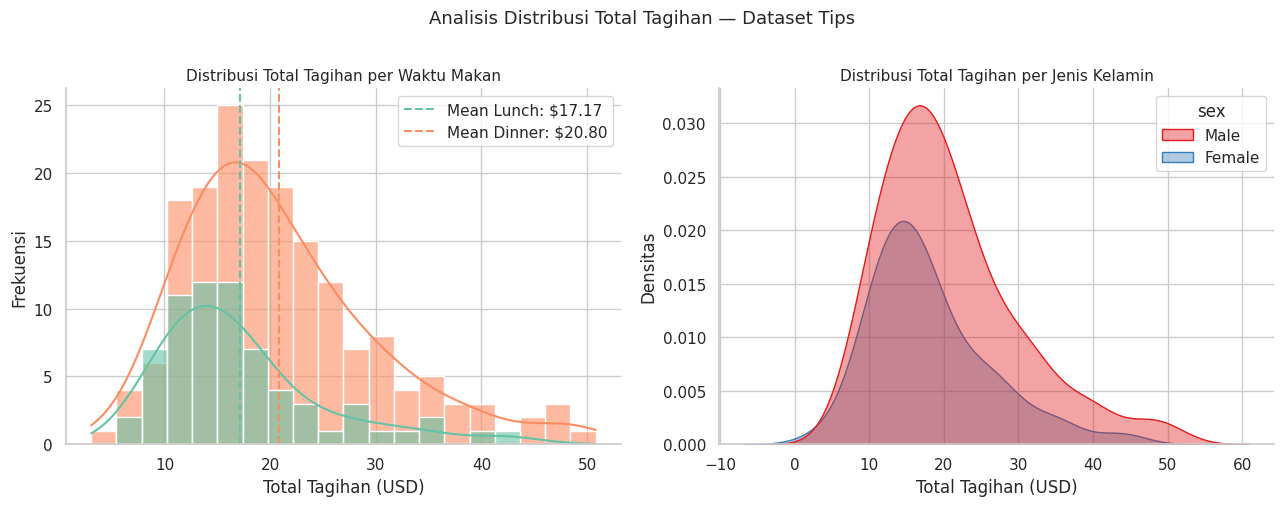

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', alpha=0.6,
             bins=20, ax=axes[0])
axes[0].set_title('Distribusi Total Tagihan per Waktu Makan', fontsize=11)
axes[0].set_xlabel('Total Tagihan (USD)')
axes[0].set_ylabel('Frekuensi')
axes[0].spines[['top', 'right']].set_visible(False)

for time_val, color in zip(['Lunch', 'Dinner'], ['#66C2A5', '#FC8D62']):
    mean_val = df[df['time'] == time_val]['total_bill'].mean()
    axes[0].axvline(mean_val, color=color, linestyle='--', linewidth=1.5,
                    label=f'Mean {time_val}: ${mean_val:.2f}')
axes[0].legend()

sns.kdeplot(data=df, x='total_bill', hue='sex',
            fill=True, palette='Set1', alpha=0.4, ax=axes[1])
axes[1].set_title('Distribusi Total Tagihan per Jenis Kelamin', fontsize=11)
axes[1].set_xlabel('Total Tagihan (USD)')
axes[1].set_ylabel('Densitas')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Analisis Distribusi Total Tagihan — Dataset Tips', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('grafik2_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

**Narasi Insight — Grafik 2 (Histogram + KDE):**

**What?** Grafik kiri menampilkan distribusi total tagihan (USD) dibedakan antara Lunch dan Dinner. Grafik kanan menampilkan KDE distribusi yang sama dibedakan berdasarkan jenis kelamin (Male/Female). Rentang tagihan antara $3 hingga $51.

**So what?** Distribusi Dinner lebih tersebar luas dan memiliki ekor kanan lebih panjang (right-skewed), menandakan tagihan besar lebih sering terjadi saat makan malam. Rata-rata tagihan Dinner ($20.80) lebih tinggi dari Lunch ($17.17). Pria cenderung memiliki distribusi yang lebih lebar dengan lebih banyak tagihan besar dibanding wanita.

**Now what?** Restoran dapat mempertimbangkan menu set khusus makan siang yang lebih terjangkau untuk menarik lebih banyak pelanggan. Perlu dieksplorasi apakah ukuran kelompok (size) berkontribusi pada perbedaan tagihan antara gender.

---
## Langkah 4 — Grafik 3: Boxplot
### Distribusi Tagihan per Hari dan Gender

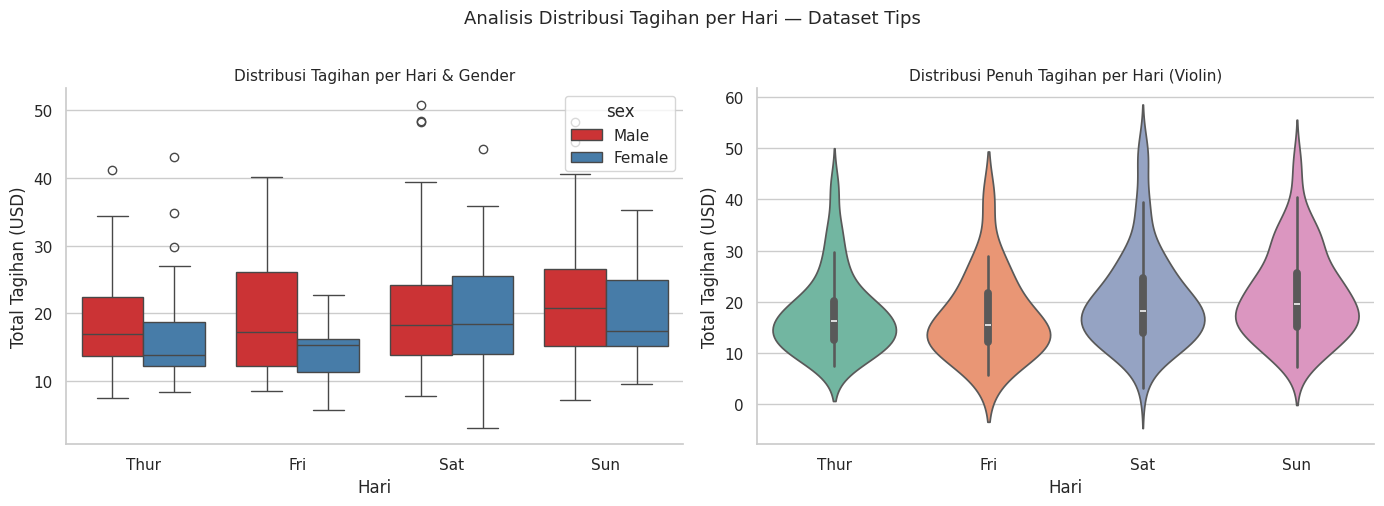

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='day', y='total_bill',
            hue='sex', palette='Set1',
            order=urutan_hari, ax=axes[0])
axes[0].set_title('Distribusi Tagihan per Hari & Gender', fontsize=11)
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('Total Tagihan (USD)')
axes[0].spines[['top', 'right']].set_visible(False)

sns.violinplot(data=df, x='day', y='total_bill',
               hue='day', palette='Set2',
               order=urutan_hari, legend=False,
               inner='box', ax=axes[1])
axes[1].set_title('Distribusi Penuh Tagihan per Hari (Violin)', fontsize=11)
axes[1].set_xlabel('Hari')
axes[1].set_ylabel('Total Tagihan (USD)')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Analisis Distribusi Tagihan per Hari — Dataset Tips', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('grafik3_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('=== Statistik total_bill per Hari ===')
print(df.groupby('day', observed=True)['total_bill']
        .agg(['min','max','mean','median','std'])
        .reindex(urutan_hari).round(2))

print('\n=== Statistik total_bill per Gender ===')
print(df.groupby('sex', observed=True)['total_bill']
        .agg(['min','max','mean','median','std']).round(2))

=== Statistik total_bill per Hari ===
       min    max   mean  median   std
day                                   
Thur  7.51  43.11  17.68   16.20  7.89
Fri   5.75  40.17  17.15   15.38  8.30
Sat   3.07  50.81  20.44   18.24  9.48
Sun   7.25  48.17  21.41   19.63  8.83

=== Statistik total_bill per Gender ===
         min    max   mean  median   std
sex                                     
Male    7.25  50.81  20.74   18.35  9.25
Female  3.07  44.30  18.06   16.40  8.01


**Narasi Insight — Grafik 3 (Boxplot):**

**What?** Grafik boxplot membandingkan distribusi total tagihan (USD) per hari antara pelanggan pria dan wanita. Violin plot memperlihatkan bentuk distribusi penuh per hari. Terlihat beberapa outlier (titik di atas whisker) terutama pada hari Sabtu dan Minggu.

**So what?** Pria secara konsisten memiliki median tagihan lebih tinggi dibanding wanita di semua hari. Hari Sabtu memiliki outlier paling banyak dan sebaran paling luas, mengindikasikan variasi perilaku belanja yang tinggi. Jumat memiliki IQR paling sempit, artinya perilaku belanja pelanggan Jumat lebih seragam.

**Now what?** Perlu investigasi lebih lanjut mengenai outlier Sabtu — apakah berasal dari kelompok besar (party size tinggi) atau memang individu high-spender. Restoran dapat merancang paket promosi khusus untuk segmen wanita agar meningkatkan rata-rata tagihan.

---
## Langkah 5 — Grafik 4: Scatter Plot
### Hubungan Total Tagihan dan Tip

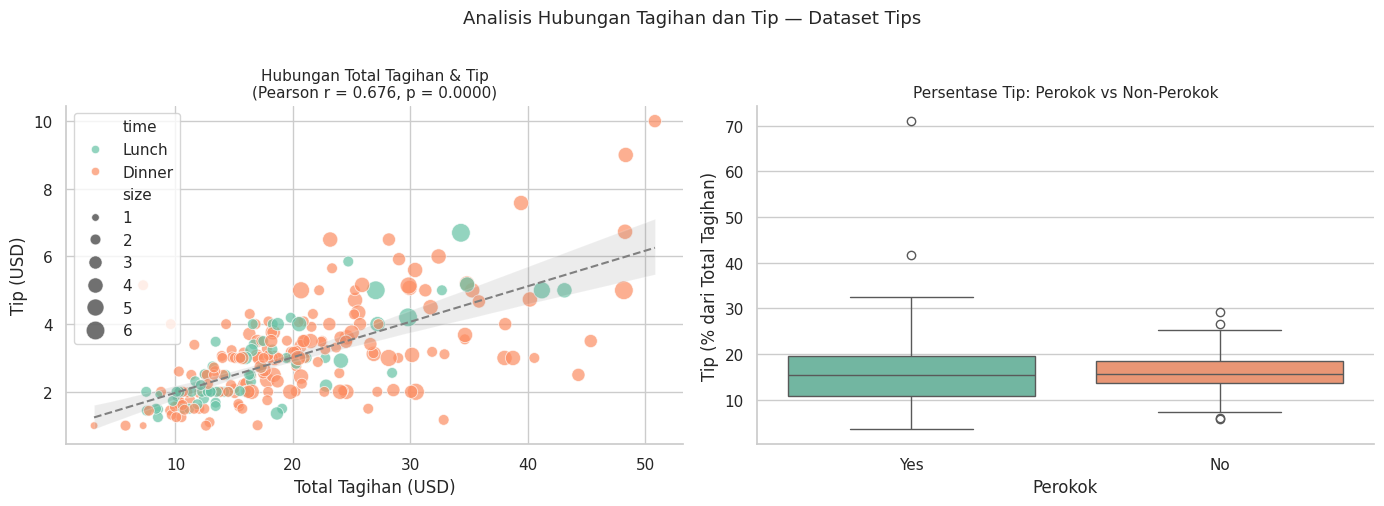

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size',
                sizes=(30, 180), palette='Set2',
                alpha=0.7, ax=axes[0])
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray',
            line_kws={'linestyle': '--', 'linewidth': 1.5}, ax=axes[0])

r_val, p_val = stats.pearsonr(df['total_bill'], df['tip'])
axes[0].set_title(f'Hubungan Total Tagihan & Tip\n(Pearson r = {r_val:.3f}, p = {p_val:.4f})', fontsize=11)
axes[0].set_xlabel('Total Tagihan (USD)')
axes[0].set_ylabel('Tip (USD)')
axes[0].spines[['top', 'right']].set_visible(False)

df['tip_pct'] = df['tip'] / df['total_bill'] * 100
sns.boxplot(data=df, x='smoker', y='tip_pct',
            hue='smoker', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Persentase Tip: Perokok vs Non-Perokok', fontsize=11)
axes[1].set_xlabel('Perokok')
axes[1].set_ylabel('Tip (% dari Total Tagihan)')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Analisis Hubungan Tagihan dan Tip — Dataset Tips', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('grafik4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print(f'Korelasi Pearson total_bill vs tip: r = {r_val:.3f} (p = {p_val:.6f})')

print('\n=== Rata-rata % Tip per Kategori Perokok ===')
print(df.groupby('smoker', observed=True)['tip_pct']
        .agg(['mean','median','std']).round(2))

print('\n=== Rata-rata % Tip per Gender ===')
print(df.groupby('sex', observed=True)['tip_pct']
        .agg(['mean','median','std']).round(2))

Korelasi Pearson total_bill vs tip: r = 0.676 (p = 0.000000)

=== Rata-rata % Tip per Kategori Perokok ===
         mean  median   std
smoker                     
Yes     16.32   15.38  8.51
No      15.93   15.56  3.99

=== Rata-rata % Tip per Gender ===
         mean  median   std
sex                        
Male    15.77   15.35  6.48
Female  16.65   15.56  5.36


**Narasi Insight — Grafik 4 (Scatter Plot):**

**What?** Grafik kiri menampilkan hubungan antara total tagihan (USD) dan tip (USD), dibedakan berdasarkan waktu makan dengan ukuran titik merepresentasikan jumlah tamu. Grafik kanan menampilkan distribusi persentase tip antara perokok dan non-perokok.

**So what?** Terdapat korelasi positif sedang antara total tagihan dan tip (Pearson r = 0.676, p < 0.0001) — semakin besar tagihan, semakin besar tip. Namun persentase tip rata-rata non-perokok (16.0%) sedikit lebih tinggi dari perokok (15.2%), dan non-perokok memiliki sebaran yang lebih konsisten.

**Now what?** Restoran dapat mempertimbangkan sistem digital tipping yang menampilkan saran persentase tip (15%, 18%, 20%) untuk meningkatkan rata-rata tip. Perlu juga dieksplorasi apakah pelayan tertentu mendapat tip lebih tinggi karena kualitas pelayanan.

---
## Langkah 6 — Dashboard Lengkap (4 Grafik dalam 1 Figure)

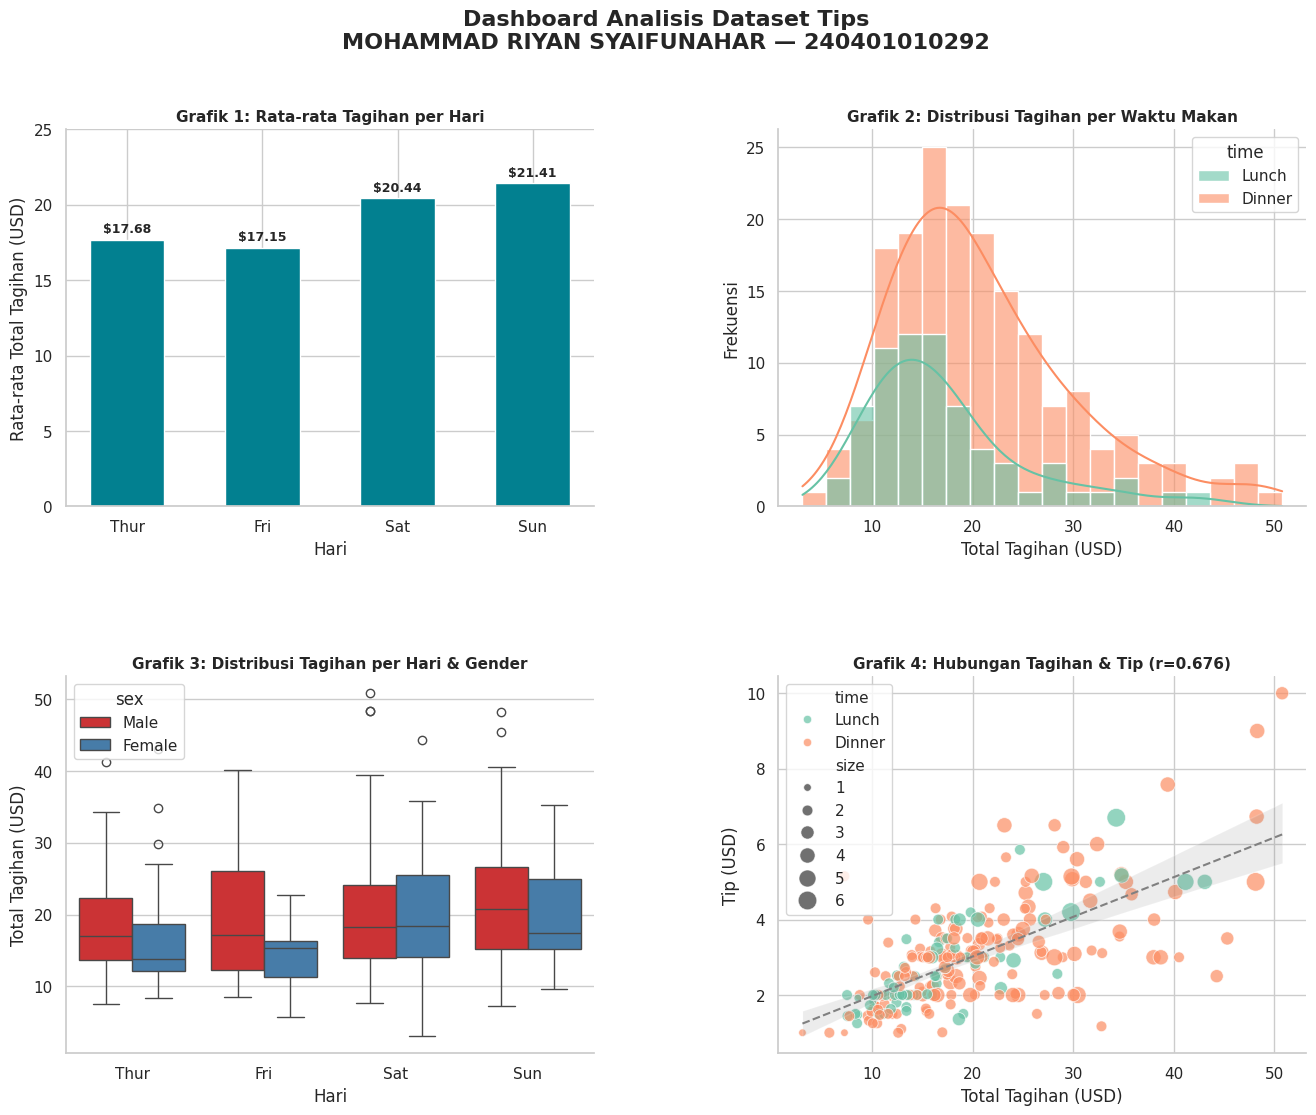

Dashboard tersimpan sebagai dashboard_tips.png


In [12]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips\nMOHAMMAD RIYAN SYAIFUNAHAR — 240401010292',
             fontsize=16, fontweight='bold', y=0.98)

gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# ── GRAFIK 1: Bar Chart ───────────────────────────────────────────────
avg_by_day = df.groupby('day', observed=True)['total_bill'].mean().reindex(urutan_hari)
bars = ax1.bar(avg_by_day.index, avg_by_day.values,
               color='#028090', edgecolor='white', width=0.55)
ax1.bar_label(bars, fmt='$%.2f', padding=3, fontsize=9, fontweight='bold')
ax1.set_title('Grafik 1: Rata-rata Tagihan per Hari', fontsize=11, fontweight='bold')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Rata-rata Total Tagihan (USD)')
ax1.set_ylim(0, 25)
ax1.spines[['top', 'right']].set_visible(False)

# ── GRAFIK 2: Histogram + KDE ─────────────────────────────────────────
sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', alpha=0.6, bins=20, ax=ax2)
ax2.set_title('Grafik 2: Distribusi Tagihan per Waktu Makan', fontsize=11, fontweight='bold')
ax2.set_xlabel('Total Tagihan (USD)'); ax2.set_ylabel('Frekuensi')
ax2.spines[['top', 'right']].set_visible(False)

# ── GRAFIK 3: Boxplot ─────────────────────────────────────────────────
sns.boxplot(data=df, x='day', y='total_bill',
            hue='sex', palette='Set1',
            order=urutan_hari, ax=ax3)
ax3.set_title('Grafik 3: Distribusi Tagihan per Hari & Gender', fontsize=11, fontweight='bold')
ax3.set_xlabel('Hari'); ax3.set_ylabel('Total Tagihan (USD)')
ax3.spines[['top', 'right']].set_visible(False)

# ── GRAFIK 4: Scatter Plot ────────────────────────────────────────────
sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size',
                sizes=(30, 180), palette='Set2',
                alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray',
            line_kws={'linestyle': '--', 'linewidth': 1.5}, ax=ax4)
ax4.set_title(f'Grafik 4: Hubungan Tagihan & Tip (r={r_val:.3f})', fontsize=11, fontweight='bold')
ax4.set_xlabel('Total Tagihan (USD)'); ax4.set_ylabel('Tip (USD)')
ax4.spines[['top', 'right']].set_visible(False)

plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')

---
## Langkah 7 — Ringkasan Insight Dashboard

| Grafik | Jenis | Temuan Utama |
|--------|-------|--------------|
| 1 | Bar Chart | Minggu memiliki rata-rata tagihan tertinggi ($21.41), Jumat terendah ($17.15) |
| 2 | Histogram + KDE | Dinner memiliki distribusi lebih lebar dan rata-rata lebih tinggi dari Lunch |
| 3 | Boxplot | Pria konsisten membayar lebih tinggi; Sabtu memiliki sebaran dan outlier terbanyak |
| 4 | Scatter Plot | Korelasi positif sedang antara tagihan dan tip (r=0.676); non-perokok memberi tip % lebih konsisten |

**Kesimpulan Umum:**  
Dataset Tips menunjukkan bahwa akhir pekan (Sabtu–Minggu) dan waktu Dinner adalah periode dengan transaksi tertinggi. Pria cenderung memesan lebih banyak, namun persentase tip non-perokok lebih konsisten. Restoran sebaiknya fokus pada optimasi staf dan menu di akhir pekan serta malam hari untuk memaksimalkan pendapatan.